In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pwr=pd.read_excel("data/PGCB_date_power_demand.xlsx",index_col="datetime")
pwr.index = pd.to_datetime(pwr.index)

w= pd.read_excel("data/weather_data.xlsx", skiprows=3)
en = pd.read_csv("data/economic_full_1.csv")

#pwr=power demand
#w=weather
#en=macroecon indicator

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
print(pwr)

                     generation_mw  demand_mw  load_shedding   gas  liquid_fuel  coal  hydro  solar  wind  india_bheramara_hvdc  india_tripura  india_adani  nepal       remarks
datetime                                                                                                                                                                        
2015-04-19 22:00:00         6323.0       6323              0     0            0     0      0    NaN   NaN                     0              0          NaN    NaN           NaN
2015-04-19 21:00:00         6667.0       6667              0     0            0     0      0    NaN   NaN                     0              0          NaN    NaN           NaN
2015-04-19 19:00:00         6897.0       6897              0  4415         1836   161     41    NaN   NaN                   444              0          NaN    NaN           NaN
2015-04-19 18:30:00         6933.0       6933              0  4423         1862   159     45    NaN   NaN          

In [ ]:
pwr = pwr.sort_index()

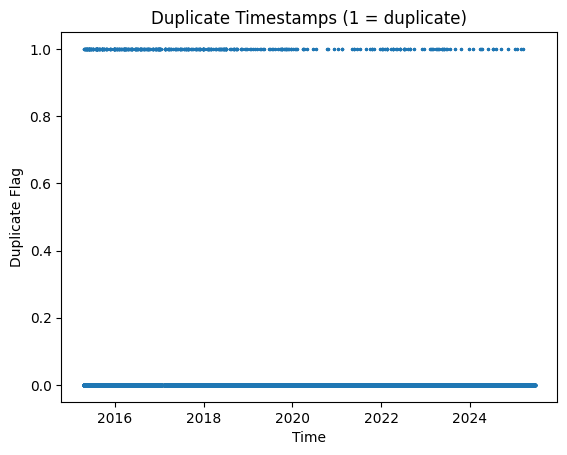

In [ ]:
dup_mask = pwr.index.duplicated(keep=False)
plt.figure()
plt.scatter(pwr.index, dup_mask.astype(int), s=2)
plt.title("Duplicate Timestamps (1 = duplicate)")
plt.xlabel("Time")
plt.ylabel("Duplicate Flag")
plt.show()

In [ ]:
pwr.index.duplicated().sum()

np.int64(432)

In [ ]:
pwr = pwr.groupby(pwr.index).mean(numeric_only=True)

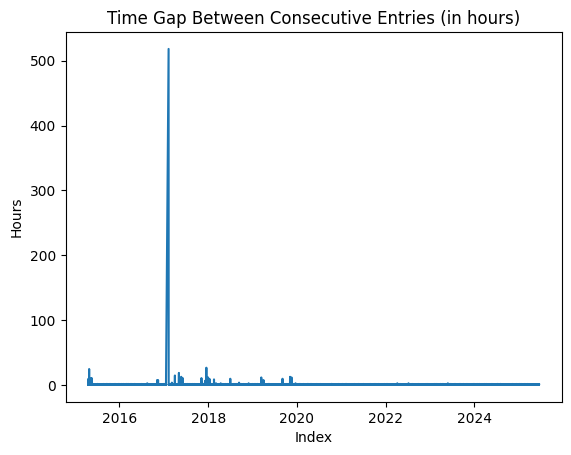

In [ ]:
time_diff = pwr.index.to_series().diff().dt.total_seconds() / 3600  # in hours

plt.figure()
plt.plot(time_diff)
plt.title("Time Gap Between Consecutive Entries (in hours)")
plt.xlabel("Index")
plt.ylabel("Hours")
plt.show()

In [ ]:
pwr.index.to_series().diff().value_counts().head(10)

datetime
0 days 01:00:00    83649
0 days 00:30:00     8336
0 days 02:00:00      178
0 days 03:00:00       11
0 days 01:30:00        8
0 days 07:00:00        4
0 days 10:00:00        4
0 days 11:00:00        4
0 days 12:00:00        4
0 days 09:00:00        4
Name: count, dtype: int64

In [ ]:
pwr = pwr.asfreq('h')
pwr = pwr.fillna(
    pwr.rolling(5, min_periods=1).mean()
)

In [ ]:
#time features
pwr['hour'] = pwr.index.hour
pwr['dayofweek'] = pwr.index.dayofweek
pwr['month'] = pwr.index.month

In [ ]:
missing_pct = (pwr.isnull().sum() / len(pwr)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
print(missing_pct)

nepal                   94.229021
india_adani             92.093243
wind                    79.865546
solar                   23.966061
generation_mw            0.795726
liquid_fuel              0.795726
gas                      0.795726
load_shedding            0.795726
demand_mw                0.795726
coal                     0.795726
hydro                    0.795726
india_tripura            0.795726
india_bheramara_hvdc     0.795726
dtype: float64


In [ ]:
corr = pwr.corr(numeric_only=True)['demand_mw']
corr.sort_values()

dayofweek              -0.033737
month                  -0.004150
liquid_fuel             0.006649
generation_mw           0.008033
wind                    0.023172
hydro                   0.080835
nepal                   0.112981
hour                    0.211476
solar                   0.242138
load_shedding           0.381025
india_tripura           0.450490
india_bheramara_hvdc    0.460815
gas                     0.497844
india_adani             0.630739
coal                    0.643646
demand_mw               1.000000
Name: demand_mw, dtype: float64

dropping the features nepal, remarks, wind as the percentange of data being na is very high(>80%) as well have low correlation with demand_mw. interpolating them is basically useless

but india_adani has high correlation to demand_mw.

In [ ]:
subset = pwr[pwr['india_adani'].notna()]
percent = (subset['india_adani'].sum() / subset['demand_mw'].sum()) * 100
print(f"India Adani contribution: {percent:.2f}%")

India Adani contribution: 7.74%


also contribution to demand_mw is decent

In [ ]:
pwr['india_adani'] = pwr['india_adani'].fillna(0)

In [ ]:
pwr = pwr.drop(columns=['nepal', 'remarks', 'wind'], errors='ignore')

Solar data is handled differently

In [ ]:
mask = pwr['solar'].isna() & ((pwr['hour'] < 6) | (pwr['hour'] > 18))
pwr.loc[mask, 'solar'] = 0

The solar energy during night is almost 0

In [ ]:
pwr['solar'] = pwr['solar'].fillna(
    pwr['solar'].rolling(5, min_periods=1).mean()
)

using rolling mean to replace day time na values

In [ ]:
pwr = pwr.fillna(
    pwr.rolling(5, min_periods=1).mean()
)

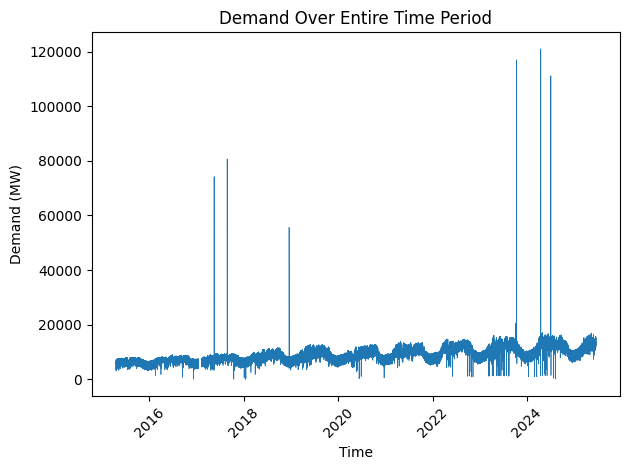

In [ ]:
pwr = pwr.sort_index()

plt.figure()
plt.plot(pwr.index, pwr['demand_mw'], linewidth=0.5)
plt.title("Demand Over Entire Time Period")
plt.xlabel("Time")
plt.ylabel("Demand (MW)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
low = pwr['demand_mw'].quantile(0.01)
high = pwr['demand_mw'].quantile(0.99)

pwr['demand_mw'] = pwr['demand_mw'].clip(lower=low, upper=high)

Extreme spikes in demand were observed and treated as anomalies. These were handled using percentile-based clipping (1st–99th percentile) to remove unrealistic values while preserving the overall trend.

In [ ]:
keep = [
    'NY.GDP.MKTP.CD',
    'SP.POP.TOTL',
    'SP.URB.TOTL.IN.ZS',
    'EG.ELC.ACCS.ZS',
    'EG.USE.ELEC.KH.PC',
    'NV.IND.TOTL.ZS',
    'NV.SRV.TOTL.ZS'
]
#indicator codes from global econ data that affect eletricity usage the most
filt=en['Indicator Code'].isin(keep)
en = en[filt]

In [ ]:
en_long = en.melt(
    id_vars=['Indicator Code'],
    var_name='year',
    value_name='value'
)

en_long = en_long[en_long['year'].str.isnumeric()]
en_long['year'] = en_long['year'].astype(int)

en_pivot = en_long.pivot(
    index='year',
    columns='Indicator Code',
    values='value'
).reset_index()

In [ ]:
econ_dict = {}

for col in en_pivot.columns:
    if col != 'year':
        econ_dict[col] = dict(zip(en_pivot['year'], en_pivot[col]))

pwr['year'] = pwr.index.year

for col in econ_dict:
    pwr[col] = pwr['year'].map(econ_dict[col])

pwr = pwr.ffill()

In [ ]:
pwr = pwr.rename(columns={
    'NY.GDP.MKTP.CD': 'gdp',
    'SP.POP.TOTL': 'population',
    'SP.URB.TOTL.IN.ZS': 'urban_pct',
    'EG.ELC.ACCS.ZS': 'electricity_access',
    'EG.USE.ELEC.KH.PC': 'electricity_per_capita',
    'NV.IND.TOTL.ZS': 'industry_pct',
    'NV.SRV.TOTL.ZS': 'services_pct'
})

pwr.head()

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,india_bheramara_hvdc,india_tripura,india_adani,hour,dayofweek,month,year,electricity_access,electricity_per_capita,industry_pct,services_pct,gdp,population,urban_pct
datetime,,,,,,,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,4821.0,4821.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,6,4,2015,74.0,348.932681,26.831395,53.713832,1.951470e+11,159383179.0,29.53951
2015-04-19 01:00:00,3612.0,4145.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,6,4,2015,74.0,348.932681,26.831395,53.713832,1.951470e+11,159383179.0,29.53951
2015-04-19 02:00:00,3727.0,4145.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,6,4,2015,74.0,348.932681,26.831395,53.713832,1.951470e+11,159383179.0,29.53951
2015-04-19 03:00:00,3632.0,4145.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,6,4,2015,74.0,348.932681,26.831395,53.713832,1.951470e+11,159383179.0,29.53951
2015-04-19 04:00:00,3641.0,4145.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,6,4,2015,74.0,348.932681,26.831395,53.713832,1.951470e+11,159383179.0,29.53951


In [ ]:
keep_w = [
    'time',
    'temperature_2m (°C)',
    'relative_humidity_2m (%)',
    'apparent_temperature (°C)',
    'cloud_cover (%)',
    'sunshine_duration (s)'
]

w = w[keep_w]

In [ ]:
w

,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),cloud_cover (%),sunshine_duration (s)
0,2014-01-01 00:00:00,13.9,89,13.3,0,0.0
1,2014-01-01 01:00:00,13.6,91,13.2,0,0.0
2,2014-01-01 02:00:00,13.3,91,12.8,0,0.0
3,2014-01-01 03:00:00,13.0,92,12.5,0,0.0
4,2014-01-01 04:00:00,12.7,93,12.2,0,0.0
...,...,...,...,...,...,...
107299,2026-03-29 19:00:00,25.5,81,29.0,10,0.0
107300,2026-03-29 20:00:00,25.5,82,29.4,25,0.0
107301,2026-03-29 21:00:00,25.0,83,29.0,16,0.0
107302,2026-03-29 22:00:00,24.5,87,28.8,5,0.0


In [ ]:
w['time'] = pd.to_datetime(w['time'])
w = w.set_index('time')
w = w.sort_index()

w = w.asfreq('h')

pwr = pwr.join(w, how='left')
pwr

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,india_bheramara_hvdc,india_tripura,india_adani,hour,dayofweek,month,year,electricity_access,electricity_per_capita,industry_pct,services_pct,gdp,population,urban_pct,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),cloud_cover (%),sunshine_duration (s)
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,4821.0,4821.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,6,4,2015,74.0,348.932681,26.831395,53.713832,1.951470e+11,159383179.0,29.53951,25.7,87,29.6,9,0.00
2015-04-19 01:00:00,3612.0,4145.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,6,4,2015,74.0,348.932681,26.831395,53.713832,1.951470e+11,159383179.0,29.53951,25.3,88,30.0,26,0.00
2015-04-19 02:00:00,3727.0,4145.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,6,4,2015,74.0,348.932681,26.831395,53.713832,1.951470e+11,159383179.0,29.53951,24.9,90,29.6,32,0.00
2015-04-19 03:00:00,3632.0,4145.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,6,4,2015,74.0,348.932681,26.831395,53.713832,1.951470e+11,159383179.0,29.53951,25.0,90,29.3,30,0.00
2015-04-19 04:00:00,3641.0,4145.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,6,4,2015,74.0,348.932681,26.831395,53.713832,1.951470e+11,159383179.0,29.53951,25.2,91,30.3,67,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,11896.00,0.0,5678.0,490.0,3470.0,132.0,219.0,924.0,24.0,864.0,8,1,6,2025,99.5,602.674747,34.097174,51.416655,4.501190e+11,173562364.0,32.67832,27.5,86,31.3,99,1306.80
2025-06-17 09:00:00,12290.0,12290.00,0.0,6065.0,531.0,3491.0,132.0,203.0,924.0,24.0,866.0,9,1,6,2025,99.5,602.674747,34.097174,51.416655,4.501190e+11,173562364.0,32.67832,28.5,82,32.2,100,3600.00
2025-06-17 10:00:00,12443.0,12443.00,0.0,5900.0,552.0,3601.0,172.0,215.0,923.0,26.0,985.0,10,1,6,2025,99.5,602.674747,34.097174,51.416655,4.501190e+11,173562364.0,32.67832,29.1,81,33.3,99,3600.00


In [ ]:
lags = [1,2,3,6,12,24,48,168]

for lag in lags:
    pwr[f'lag_{lag}'] = pwr['demand_mw'].shift(lag)

pwr['diff_1'] = pwr['demand_mw'].diff(1)
pwr['diff_24'] = pwr['demand_mw'].diff(24)

pwr['roll_std_24'] = pwr['demand_mw'].rolling(24).std().shift(1)

#rolling features
pwr['roll_mean_3'] = pwr['demand_mw'].rolling(3).mean().shift(1)
pwr['roll_mean_24'] = pwr['demand_mw'].rolling(24).mean().shift(1)
pwr['roll_mean_12'] = pwr['demand_mw'].rolling(12).mean().shift(1)
#shift 1 was introduced to prevent data leakage

pwr['target'] = pwr['demand_mw'].shift(-1)

pwr = pwr.dropna()
#Initial rows with missing vsalues arising from lag and rolling feature creation were removed, 
#as they lack sufficient historical context for modeling.

pwr

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,india_bheramara_hvdc,india_tripura,india_adani,hour,dayofweek,month,year,electricity_access,electricity_per_capita,industry_pct,services_pct,gdp,population,urban_pct,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),cloud_cover (%),sunshine_duration (s),lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,lag_48,lag_168,diff_1,diff_24,roll_std_24,roll_mean_3,roll_mean_24,roll_mean_12,target
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-04-26 00:00:00,6167.000000,6167.000000,0.0,4958.000000,554.000000,156.000000,46.0000,0.0,453.000000,0.0,0.0,0,6,4,2015,74.0,348.932681,26.831395,53.713832,1.951470e+11,159383179.0,29.53951,22.0,91,24.6,92,0.00,6207.500000,5679.333333,5491.500000,4623.000000,4214.0,5197.0,4145.05,4821.00,-40.500000,970.000000,696.776263,5792.777778,4775.524306,5135.694444,5886.333333
2015-04-26 01:00:00,5886.333333,5886.333333,0.0,4829.458333,615.854167,155.833333,45.8125,0.0,452.583333,0.0,0.0,1,6,4,2015,74.0,348.932681,26.831395,53.713832,1.951470e+11,159383179.0,29.53951,21.8,93,24.7,97,0.00,6167.000000,6207.500000,5679.333333,6248.000000,4380.0,4987.0,4145.05,4145.05,-280.666667,899.333333,748.499757,6017.944444,4815.940972,5298.444444,6017.944444
2015-04-26 02:00:00,6017.944444,6017.944444,0.0,4904.944444,620.722222,156.111111,46.0000,0.0,452.611111,0.0,0.0,2,6,4,2015,74.0,348.932681,26.831395,53.713832,1.951470e+11,159383179.0,29.53951,21.6,94,24.7,99,0.00,5886.333333,6167.000000,6207.500000,6167.000000,4526.0,4703.0,4145.05,4145.05,131.611111,1314.944444,779.313298,6086.944444,4853.413194,5423.972222,6187.250000
2015-04-26 03:00:00,6187.250000,6187.250000,0.0,4943.750000,588.750000,156.000000,46.0000,0.0,452.750000,0.0,0.0,3,6,4,2015,74.0,348.932681,26.831395,53.713832,1.951470e+11,159383179.0,29.53951,21.4,94,24.7,84,0.00,6017.944444,5886.333333,6167.000000,5491.500000,4653.0,4510.0,4145.05,4145.05,169.305556,1677.250000,813.741651,6023.759259,4908.202546,5548.300926,6167.000000
2015-04-26 04:00:00,6167.000000,6167.000000,0.0,4958.000000,554.000000,156.000000,46.0000,0.0,453.000000,0.0,0.0,4,6,4,2015,74.0,348.932681,26.831395,53.713832,1.951470e+11,159383179.0,29.53951,21.5,94,24.6,92,0.00,6187.250000,6017.944444,5886.333333,5679.333333,4511.0,4230.0,4145.05,4145.05,-20.250000,1937.000000,849.301957,6030.509259,4978.087963,5676.155093,6167.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 07:00:00,11745.000000,11745.000000,0.0,5614.000000,494.000000,3487.000000,132.0000,128.0,924.000000,26.0,874.0,7,1,6,2025,99.5,602.674747,34.097174,51.416655,4.501190e+11,173562364.0,32.67832,27.0,89,31.7,100,0.00,11805.000000,12062.000000,12698.000000,14115.000000,15034.0,12646.0,13078.00,11787.00,-60.000000,-901.000000,966.088539,12188.333333,13800.750000,13963.166667,11896.000000
2025-06-17 08:00:00,11896.000000,11896.000000,0.0,5678.000000,490.000000,3470.000000,132.0000,219.0,924.000000,24.0,864.0,8,1,6,2025,99.5,602.674747,34.097174,51.416655,4.501190e+11,173562364.0,32.67832,27.5,86,31.3,99,1306.80,11745.000000,11805.000000,12062.000000,13719.000000,15035.0,12876.0,13319.00,11642.00,151.000000,-980.000000,1028.408605,11870.666667,13763.208333,13689.083333,12290.000000
2025-06-17 09:00:00,12290.000000,12290.000000,0.0,6065.000000,531.000000,3491.000000,132.0000,203.0,924.000000,24.0,866.0,9,1,6,2025,99.5,602.674747,34.097174,51.416655,4.501190e+11,173562364.0,32.67832,28.5,82,32.2,100,3600.00,11896.000000,11745.000000,11805.000000,13280.000000,15000.0,13155.0,13631.00,11635.00,394.000000,-865.000000,1083.165041,11815.333333,13722.375000,13427.500000,12443.000000


In [ ]:
cols = ['temperature_2m (°C)', 'apparent_temperature (°C)', 'relative_humidity_2m (%)']

# standardize (z-score)
z = (pwr[cols] - pwr[cols].mean()) / pwr[cols].std()

# combine
pwr['thermal_index'] = z.mean(axis=1)

A composite thermal index was created by combining temperature, apparent temperature, and humidity to capture overall environmental conditions affecting electricity demand.

In [ ]:
pwr = pwr.drop(columns=[
    'temperature_2m (°C)',
    'relative_humidity_2m (%)',
    'apparent_temperature (°C)'
])

Correlation analysis revealed that lag-based features exhibited the strongest relationship with demand, confirming the temporal dependency of electricity consumption. Economic indicators showed moderate correlation, indicating their influence on long-term demand levels. Weather variables such as temperature had a noticeable but weaker impact. Load shedding demonstrated moderate correlation, suggesting its role as an indicator of system stress. Several features with negligible correlation were removed to reduce noise and improve model performance.

In [ ]:
features = [col for col in pwr.columns if col not in ['target', 'demand_mw']]
print(features)

['generation_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'india_bheramara_hvdc', 'india_tripura', 'india_adani', 'hour', 'dayofweek', 'month', 'year', 'electricity_access', 'electricity_per_capita', 'industry_pct', 'services_pct', 'gdp', 'population', 'urban_pct', 'cloud_cover (%)', 'sunshine_duration (s)', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_24', 'lag_48', 'lag_168', 'diff_1', 'diff_24', 'roll_std_24', 'roll_mean_3', 'roll_mean_24', 'roll_mean_12', 'thermal_index']


In [ ]:
train = pwr[pwr.index.year < 2023]
test = pwr[pwr.index.year >= 2023]

In [ ]:
X_train = train[features]
y_train = train['target']

X_test = test[features]
y_test = test['target']

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

model2 = LinearRegression()
model2.fit(X_train, y_train)

preds2 = model2.predict(X_test)

mape = mean_absolute_percentage_error(y_test, preds2)
print(f"Linear Regression error: {mape:.2%}")

Linear Regression error: 7.70%


In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor()
model.fit(X_train, y_train)

preds = model.predict(X_test)

In [ ]:

mape = mean_absolute_percentage_error(y_test, preds)
print("Xgboost error % =",mape*100,"%")

Xgboost error % = 3.145682234491371 %


In [ ]:
model3 = XGBRegressor(
    n_estimators=700,
    max_depth=4,
    learning_rate=0.02,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.2,
    reg_lambda=1.5,
    random_state=42
)

model3.fit(X_train, y_train)

preds3 = model3.predict(X_test)

mape3 = mean_absolute_percentage_error(y_test, preds3)
print(f"Improved XGBoost error: {mape3:.2%}")

Improved XGBoost error: 3.11%
